In [5]:
import os
import pandas as pd

# Find the actual dataset folder automatically
folders = os.listdir("/kaggle/input")

print("Available input folders:")
for folder in folders:
    print("📁", folder)

DATASET_PATH = os.path.join(
    "/kaggle/input",
    folders[0]
)

print("\nDataset path:")
print(DATASET_PATH)


# Find CSV files
all_csvs = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(".csv"):
            all_csvs.append(
                os.path.join(root, file)
            )

print("\nTotal CSV files:", len(all_csvs))

for path in all_csvs[:30]:
    print(path)

Available input folders:
📁 datasets

Dataset path:
/kaggle/input/datasets

Total CSV files: 2990
/kaggle/input/datasets/hiranomanabu/ransap-2022-ransomware-behavioral-features/RanSAP/dataset/extra/win2008r2-250gb-ssd/TeslaCrypt-w10dirs/TeslaCrypt-20210126_19-39-14/ata_read.csv
/kaggle/input/datasets/hiranomanabu/ransap-2022-ransomware-behavioral-features/RanSAP/dataset/extra/win2008r2-250gb-ssd/TeslaCrypt-w10dirs/TeslaCrypt-20210126_19-39-14/ata_write.csv
/kaggle/input/datasets/hiranomanabu/ransap-2022-ransomware-behavioral-features/RanSAP/dataset/extra/win2008r2-250gb-ssd/TeslaCrypt-w10dirs/TeslaCrypt-20210624_00-41-32/ata_read.csv
/kaggle/input/datasets/hiranomanabu/ransap-2022-ransomware-behavioral-features/RanSAP/dataset/extra/win2008r2-250gb-ssd/TeslaCrypt-w10dirs/TeslaCrypt-20210624_00-41-32/ata_write.csv
/kaggle/input/datasets/hiranomanabu/ransap-2022-ransomware-behavioral-features/RanSAP/dataset/extra/win2008r2-250gb-ssd/TeslaCrypt-w10dirs/TeslaCrypt-20210126_19-14-29/ata_read.

In [7]:
# ============================================
# BALANCED DATASET — NO RANDOM SAMPLING
# ============================================

RANSOMWARE_APPS = [
    "Sodinokibi",
    "Ryuk",
    "WannaCry",
    "TeslaCrypt",
    "GandCrab",
    "Darkside",
    "Cerber"
]

BENIGN_APPS = [
    "Excel",
    "SDelete",
    "Firefox",
    "AESCrypt",
    "Zip"
]

selected_parts = []

# --------------------------------------------
# RANSOMWARE
# 86 files from EACH ransomware family
# 86 × 7 = 602
# --------------------------------------------

for app in RANSOMWARE_APPS:

    app_df = files_df[
        files_df["application"] == app
    ].sort_values("path")

    selected = app_df.head(86)

    selected_parts.append(selected)

    print(
        f"{app}: {len(selected)} ransomware files"
    )


# --------------------------------------------
# BENIGN
# Take ALL benign files
# Total = 602
# --------------------------------------------

for app in BENIGN_APPS:

    app_df = files_df[
        files_df["application"] == app
    ].sort_values("path")

    selected_parts.append(app_df)

    print(
        f"{app}: {len(app_df)} benign files"
    )


# --------------------------------------------
# COMBINE
# --------------------------------------------

selected_df = pd.concat(
    selected_parts,
    ignore_index=True
)

# Sort instead of random shuffle
selected_df = selected_df.sort_values(
    ["label", "application", "path"]
).reset_index(drop=True)


# ============================================
# CHECK
# ============================================

print("\n================================")
print("FINAL BALANCED DATASET")
print("================================")

print(
    "\nTotal files:",
    len(selected_df)
)

print(
    "\nClass distribution:"
)

print(
    selected_df["label"]
    .value_counts()
)

print(
    "\nApplication distribution:"
)

print(
    selected_df["application"]
    .value_counts()
)

Sodinokibi: 86 ransomware files
Ryuk: 86 ransomware files
WannaCry: 86 ransomware files
TeslaCrypt: 86 ransomware files
GandCrab: 86 ransomware files
Darkside: 86 ransomware files
Cerber: 86 ransomware files
Excel: 122 benign files
SDelete: 120 benign files
Firefox: 120 benign files
AESCrypt: 120 benign files
Zip: 120 benign files

FINAL BALANCED DATASET

Total files: 1204

Class distribution:
label
0    602
1    602
Name: count, dtype: int64

Application distribution:
application
Excel         122
AESCrypt      120
Firefox       120
SDelete       120
Zip           120
Cerber         86
Darkside       86
GandCrab       86
Ryuk           86
Sodinokibi     86
TeslaCrypt     86
WannaCry       86
Name: count, dtype: int64


In [13]:
# ============================================
# CORRECT FEATURE EXTRACTION FOR RANSAP
# ============================================

def extract_features(df, file_path):

    features = {}

    # -----------------------------------------
    # Identify file type
    # -----------------------------------------

    is_write = "ata_write.csv" in file_path.lower()

    # -----------------------------------------
    # Assign correct column names
    # -----------------------------------------

    if is_write:

        df.columns = [
            "time_sec",
            "time_ns",
            "LBA",
            "size",
            "entropy_1",
            "entropy_2"
        ]

    else:

        df.columns = [
            "time_sec",
            "time_ns",
            "LBA",
            "size"
        ]

    # -----------------------------------------
    # Convert numeric columns
    # -----------------------------------------

    for col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df = df.dropna(
        subset=["time_sec", "LBA", "size"]
    )

    # -----------------------------------------
    # 1. Number of I/O operations
    # -----------------------------------------

    features["operation_count"] = len(df)

    # -----------------------------------------
    # 2. I/O size
    # -----------------------------------------

    features["avg_io_size"] = df["size"].mean()

    features["std_io_size"] = df["size"].std()

    features["total_io_size"] = df["size"].sum()

    # -----------------------------------------
    # 3. I/O velocity
    # -----------------------------------------

    duration = (
        df["time_sec"].max()
        - df["time_sec"].min()
    )

    features["duration"] = duration

    if duration > 0:

        features["io_velocity"] = (
            len(df) / duration
        )

    else:

        features["io_velocity"] = 0

    # -----------------------------------------
    # 4. LBA behavior
    # -----------------------------------------

    features["unique_lba_ratio"] = (
        df["LBA"].nunique()
        / len(df)
        if len(df) > 0
        else 0
    )

    features["lba_range"] = (
        df["LBA"].max()
        - df["LBA"].min()
    )

    # -----------------------------------------
    # 5. Entropy
    # Only available for write traces
    # -----------------------------------------

    if is_write:

        features["entropy_mean"] = (
            df["entropy_1"].mean()
        )

        features["entropy_std"] = (
            df["entropy_1"].std()
        )

        features["entropy_max"] = (
            df["entropy_1"].max()
        )

        features["entropy_2_mean"] = (
            df["entropy_2"].mean()
        )

    else:

        features["entropy_mean"] = 0
        features["entropy_std"] = 0
        features["entropy_max"] = 0
        features["entropy_2_mean"] = 0

    # -----------------------------------------
    # 6. Read / Write indicator
    # -----------------------------------------

    features["is_write"] = int(is_write)

    return features

In [14]:
# ============================================
# PROCESS SELECTED CSV FILES
# ============================================

training_data = []

MAX_ROWS = 5000

for i, row in selected_df.iterrows():

    path = row["path"]
    application = row["application"]
    label = row["label"]

    try:

        # Read CSV WITHOUT assuming first row is header
        df = pd.read_csv(
            path,
            header=None,
            nrows=MAX_ROWS
        )

        # Extract features
        features = extract_features(
            df,
            path
        )

        # Add labels
        features["application"] = application
        features["label"] = label

        training_data.append(features)

        if (i + 1) % 50 == 0:

            print(
                f"Processed "
                f"{i + 1}/{len(selected_df)} files"
            )

    except Exception as e:

        print(
            f"❌ Error in file {i + 1}: {e}"
        )


# Convert to ML dataframe
ml_df = pd.DataFrame(
    training_data
)

print("\n================================")
print("FEATURE EXTRACTION COMPLETE")
print("================================")

print(
    "Total samples:",
    len(ml_df)
)

print("\nFeatures:")
print(
    ml_df.columns.tolist()
)

print("\nClass distribution:")
print(
    ml_df["label"].value_counts()
)

print("\nFirst 5 rows:")
display(
    ml_df.head()
)

Processed 50/1204 files
Processed 100/1204 files
Processed 150/1204 files
Processed 200/1204 files
Processed 250/1204 files
Processed 300/1204 files
Processed 350/1204 files
Processed 400/1204 files
Processed 450/1204 files
Processed 500/1204 files
Processed 550/1204 files
Processed 600/1204 files
Processed 650/1204 files
Processed 700/1204 files
Processed 750/1204 files
Processed 800/1204 files
Processed 850/1204 files
Processed 900/1204 files
Processed 950/1204 files
Processed 1000/1204 files
Processed 1050/1204 files
Processed 1100/1204 files
Processed 1150/1204 files
Processed 1200/1204 files

FEATURE EXTRACTION COMPLETE
Total samples: 1204

Features:
['operation_count', 'avg_io_size', 'std_io_size', 'total_io_size', 'duration', 'io_velocity', 'unique_lba_ratio', 'lba_range', 'entropy_mean', 'entropy_std', 'entropy_max', 'entropy_2_mean', 'is_write', 'application', 'label']

Class distribution:
label
0    602
1    602
Name: count, dtype: int64

First 5 rows:


,operation_count,avg_io_size,std_io_size,total_io_size,duration,io_velocity,unique_lba_ratio,lba_range,entropy_mean,entropy_std,entropy_max,entropy_2_mean,is_write,application,label
0,5000,4080.1280,200.968847,20400640,4,1250.000000,1.0,57575296,0.000000,0.000000,0.000000,0.000000,0,AESCrypt,0
1,5000,4095.2832,50.685414,20476416,7,714.285714,1.0,56279224,0.991071,0.046256,0.996103,0.893370,1,AESCrypt,0
2,5000,4079.4112,204.660558,20397056,11,454.545455,1.0,57575296,0.000000,0.000000,0.000000,0.000000,0,AESCrypt,0
3,5000,4095.2832,50.685414,20476416,15,333.333333,1.0,56279224,0.990623,0.050212,0.995838,0.892901,1,AESCrypt,0
4,5000,4079.6160,202.617052,20398080,12,416.666667,1.0,54421640,0.000000,0.000000,0.000000,0.000000,0,AESCrypt,0


In [15]:
from sklearn.model_selection import train_test_split

# Features and target
X = ml_df.drop(columns=["label", "application"])
y = ml_df["label"]

# 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split remaining 30% into:
# 15% Validation + 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

print("\nClass distribution:")
print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Training: 842
Validation: 181
Testing: 181

Class distribution:
Train:
label
1    421
0    421
Name: count, dtype: int64

Validation:
label
1    91
0    90
Name: count, dtype: int64

Test:
label
0    91
1    90
Name: count, dtype: int64


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train
model.fit(X_train, y_train)

# Validation prediction
y_val_pred = model.predict(X_val)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("\nValidation Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Benign", "Ransomware"]
    )
)

Validation Accuracy: 0.9502762430939227

Validation Report:
              precision    recall  f1-score   support

      Benign       0.98      0.92      0.95        90
  Ransomware       0.93      0.98      0.95        91

    accuracy                           0.95       181
   macro avg       0.95      0.95      0.95       181
weighted avg       0.95      0.95      0.95       181



In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Final prediction on untouched test set
y_test_pred = model.predict(X_test)

# Accuracy
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("Test Accuracy:",
      test_accuracy)

print("\nTest Classification Report:")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Benign",
            "Ransomware"
        ]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)

Test Accuracy: 0.9171270718232044

Test Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.90      0.92        91
  Ransomware       0.90      0.93      0.92        90

    accuracy                           0.92       181
   macro avg       0.92      0.92      0.92       181
weighted avg       0.92      0.92      0.92       181


Confusion Matrix:
[[82  9]
 [ 6 84]]


In [18]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("Feature Importance:")
print(importance.to_string(index=False))

Feature Importance:
         Feature  Importance
       lba_range    0.166850
unique_lba_ratio    0.138355
    entropy_mean    0.112651
     std_io_size    0.094442
  entropy_2_mean    0.089986
     avg_io_size    0.085662
   total_io_size    0.081575
     entropy_std    0.074615
     io_velocity    0.058411
        duration    0.050125
     entropy_max    0.036978
        is_write    0.010351
 operation_count    0.000000


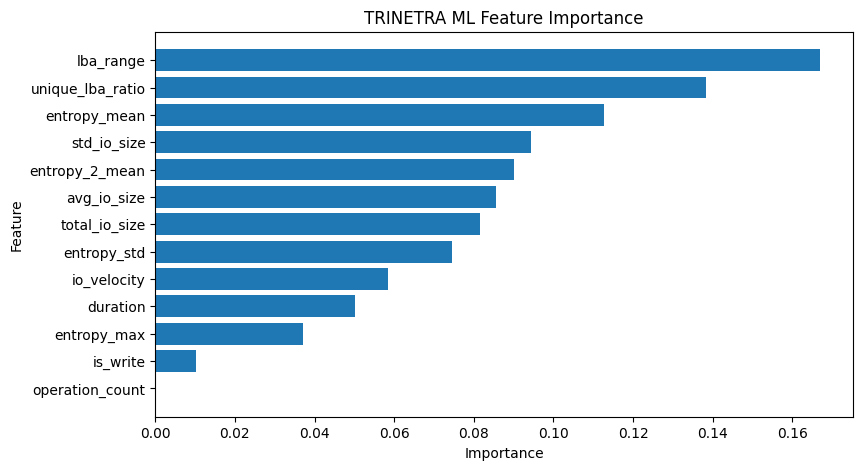

In [19]:
plt.figure(figsize=(9, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("TRINETRA ML Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [20]:
# ============================================
# TRINETRA RISK SCORE ANALYSIS
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Ransomware probability for validation set
val_prob = model.predict_proba(X_val)[:, 1]

# Convert probability to 0–100 risk score
val_risk = val_prob * 100

print("Risk Score Statistics")
print("----------------------")

print(f"Minimum Risk Score : {val_risk.min():.2f}")
print(f"Maximum Risk Score : {val_risk.max():.2f}")
print(f"Average Risk Score : {val_risk.mean():.2f}")

print("\nBenign samples:")
print(
    f"Average: "
    f"{val_risk[y_val.values == 0].mean():.2f}"
)

print(
    f"Maximum: "
    f"{val_risk[y_val.values == 0].max():.2f}"
)

print("\nRansomware samples:")
print(
    f"Average: "
    f"{val_risk[y_val.values == 1].mean():.2f}"
)

print(
    f"Minimum: "
    f"{val_risk[y_val.values == 1].min():.2f}"
)

Risk Score Statistics
----------------------
Minimum Risk Score : 0.00
Maximum Risk Score : 100.00
Average Risk Score : 51.51

Benign samples:
Average: 10.85
Maximum: 80.00

Ransomware samples:
Average: 91.71
Minimum: 39.00


In [21]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Ransomware probabilities on validation set
val_prob = model.predict_proba(X_val)[:, 1]

# Try thresholds from 0.10 to 0.90
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for threshold in thresholds:
    pred = (val_prob >= threshold).astype(int)

    precision = (
        ((pred == 1) & (y_val.values == 1)).sum()
        / max((pred == 1).sum(), 1)
    )

    recall = (
        ((pred == 1) & (y_val.values == 1)).sum()
        / max((y_val.values == 1).sum(), 1)
    )

    f1 = f1_score(y_val, pred)

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(results)

# Best threshold based on F1
best = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("BEST THRESHOLD")
print("----------------")
print(f"Threshold : {best['threshold']:.2f}")
print(f"Risk Score: {best['threshold']*100:.0f}/100")
print(f"Precision : {best['precision']:.3f}")
print(f"Recall    : {best['recall']:.3f}")
print(f"F1 Score  : {best['f1']:.3f}")

BEST THRESHOLD
----------------
Threshold : 0.44
Risk Score: 44/100
Precision : 0.928
Recall    : 0.989
F1 Score  : 0.957


In [22]:
# ============================================
# FINAL THRESHOLD CHECK ON TEST SET
# ============================================

BEST_THRESHOLD = 0.44

# Ransomware probability
test_prob = model.predict_proba(X_test)[:, 1]

# Apply selected threshold
test_pred_threshold = (
    test_prob >= BEST_THRESHOLD
).astype(int)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("================================")
print("FINAL THRESHOLD EVALUATION")
print("================================")

print(f"Risk Threshold: {BEST_THRESHOLD * 100:.0f}/100")

print(
    f"\nAccuracy : "
    f"{accuracy_score(y_test, test_pred_threshold):.3f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, test_pred_threshold):.3f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test, test_pred_threshold):.3f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test, test_pred_threshold):.3f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred_threshold
    )
)

FINAL THRESHOLD EVALUATION
Risk Threshold: 44/100

Accuracy : 0.923
Precision: 0.888
Recall   : 0.967
F1 Score : 0.926

Confusion Matrix:
[[80 11]
 [ 3 87]]


In [23]:
import joblib

# Save trained model
joblib.dump(model, "trinetra_model.pkl")

print("✅ Model saved as trinetra_model.pkl")

✅ Model saved as trinetra_model.pkl


In [24]:
import json

feature_names = X_train.columns.tolist()

with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)

print("✅ Feature names saved")

✅ Feature names saved
